# 🧬 fs06 — Face Composites by Attractiveness (FaceStats)

This notebook generates decile composites **directly from CLIP embeddings**, ensuring
perfect compatibility with:

- **fs03_embedding_extraction.ipynb** (1280-D embeddings)
- **fs04_attractiveness_model.ipynb**
- **fs05_attractiveness_inference.ipynb**

We do **not** attempt to re-embed images using open_clip.

### Key Advantages
- No embedding mismatch  
- No dimension issues (always 1280-D)  
- Composites are mathematically consistent with the trained attractiveness model  

We also optionally generate **pixel composites** for visual comparison.


## Step 1 — Imports & Paths

We load the embeddings and index created in earlier notebooks.

In [1]:
import os
import numpy as np
import json
from PIL import Image
import torch
import matplotlib.pyplot as plt

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"

EMB_PATH = "embeddings/features.npy"
IDX_PATH = "embeddings/feature_index.json"
MODEL_PATH = "models/attractiveness_regressor.pt"

print("Device:", DEVICE)


Device: mps


## Step 2 — Load the 1280-D CLIP Embeddings

We load the **same embeddings** extracted in `fs03`.

Each entry in `feature_index.json` looks like:

```{```

```"id": "SFHQ_pt4_00000001",```

```"path": "dataset_raw/part4_sd21/pretrained_features/pretrained_features/...pickle"```

```}```

In [2]:
# Load embedding matrix
X = np.load(EMB_PATH)
print("Embedding matrix:", X.shape)   # (125754, 1280)

# Load index
with open(IDX_PATH, "r") as f:
    feat_index = json.load(f)

print("Index entries:", len(feat_index))

# Build ID → row mapping
id_to_idx = {entry["id"]: i for i, entry in enumerate(feat_index)}

print("Mapping sample:", list(id_to_idx.items())[:3])


Embedding matrix: (125754, 1280)
Index entries: 125754
Mapping sample: [('SFHQ_pt4_00000001', 0), ('SFHQ_pt4_00000002', 1), ('SFHQ_pt4_00000003', 2)]


## Step 3 — Load Trained Attractiveness Regression Model

The file `models/attractiveness_regressor.pt` contains only the model **state_dict**,  
so we must rebuild the *exact same architecture* used during training  
(from `fs04_attractiveness_model.ipynb`) and then load the state_dict into it.


In [3]:
import torch
import torch.nn as nn

# Model hyperparameters
EMB_DIM = 1280

class AttractivenessRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(EMB_DIM, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.25),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.15),

            nn.Linear(128, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# Rebuild architecture
model = AttractivenessRegressor().to(DEVICE)

# Load weights
state = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state)

model.eval()
print("Model successfully loaded and ready.")


Model successfully loaded and ready.


## Step 3.5 — Build lookup dictionaries from feature_index.json

In [4]:
import json

INDEX_PATH = "embeddings/feature_index.json"

with open(INDEX_PATH, "r") as f:
    feat_index = json.load(f)

id_to_idx = {entry["id"]: i for i, entry in enumerate(feat_index)}
idx_to_id = {i: entry["id"] for i, entry in enumerate(feat_index)}

print("Loaded", len(id_to_idx), "ID mappings.")
print("Sample:", list(id_to_idx.items())[:5])


Loaded 125754 ID mappings.
Sample: [('SFHQ_pt4_00000001', 0), ('SFHQ_pt4_00000002', 1), ('SFHQ_pt4_00000003', 2), ('SFHQ_pt4_00000004', 3), ('SFHQ_pt4_00000005', 4)]


## Step 4 — Load all portrait attractiveness predictions

These predictions were created in `fs05_attractiveness_inference.ipynb`.

We use them to determine the **decile groups (1–10)**.

In [5]:
import numpy as np

PRED_PATH = "embeddings/predictions.npy"   # adjust if needed
all_scores = np.load(PRED_PATH)

scores = np.array(all_scores)
print("Score vector:", scores.shape, "min/max:", scores.min(), scores.max())


Score vector: (125754,) min/max: 0.8403608 10.771513


## Step 5 — Build Attractiveness Decile Groups

We now take the 125,754 portrait attractiveness predictions stored in  
`embeddings/predictions.npy` and divide them into **10 equally sized groups**:

- Decile 1 = lowest attractiveness  
- Decile 10 = highest attractiveness  

Each decile will later produce its own averaged composite.

In [6]:
# Create decile boundaries
sorted_idx = np.argsort(scores)
n = len(scores)
decile_groups = {}

for d in range(1, 11):
    start = int((d - 1) * n / 10)
    end   = int(d * n / 10)
    decile_groups[d] = sorted_idx[start:end]

# preview
{d: len(decile_groups[d]) for d in decile_groups}


{1: 12575,
 2: 12575,
 3: 12576,
 4: 12575,
 5: 12576,
 6: 12575,
 7: 12575,
 8: 12576,
 9: 12575,
 10: 12576}

## Step 6 — Build decile groups

We load the saved attractiveness predictions and split them into ten
equal-sized decile groups (1–10).  
Each group contains ~12,575 portrait embeddings.

In [7]:
import numpy as np

PRED_PATH = "embeddings/predictions.npy"
all_scores = np.load(PRED_PATH)

scores = np.array(all_scores)
print("Score vector:", scores.shape, "min/max:", scores.min(), scores.max())

# --- Build deciles ---
quantiles = np.quantile(scores, [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])
decile_groups = {i: [] for i in range(1, 11)}

for idx, s in enumerate(scores):
    # Determine which decile this score falls into
    d = np.searchsorted(quantiles, s) + 1
    decile_groups[d].append(idx)

# Summary
{d: len(decile_groups[d]) for d in range(1, 11)}


Score vector: (125754,) min/max: 0.8403608 10.771513


{1: 12576,
 2: 12575,
 3: 12575,
 4: 12576,
 5: 12575,
 6: 12575,
 7: 12576,
 8: 12575,
 9: 12575,
 10: 12576}

## Step 6.5 — Define a robust face loader

This helper locates each portrait using multiple filename patterns
(`.png`, `.jpg`, `_processed.png`, etc.).  
`make_composite_streaming()` relies on this function.


In [8]:
import os
from PIL import Image

PREP_DIR = "FaceStats_preprocessed_test"

def load_face(image_id):
    """
    Loads a face image by ID, checking several filename variations.
    """
    candidates = [
        os.path.join(PREP_DIR, f"{image_id}_processed.png"),
        os.path.join(PREP_DIR, f"{image_id}_processed.jpg"),
        os.path.join(PREP_DIR, f"{image_id}_processed.jpeg"),
        os.path.join(PREP_DIR, f"{image_id}.png"),
        os.path.join(PREP_DIR, f"{image_id}.jpg"),
        os.path.join(PREP_DIR, f"{image_id}.jpeg"),
    ]
    
    for p in candidates:
        if os.path.exists(p):
            return Image.open(p).convert("RGB")

    raise FileNotFoundError(f"No image found for image_id: {image_id}")


# 🟧 **Step 7A — Load a portrait image by ID (with filename fallbacks)**

We load individual portrait images on demand during composite generation.  
Because the preprocessed dataset contains filenames with multiple possible patterns (e.g., `*_processed.png`, `.jpg`, `.jpeg`), we try all variants to reliably locate each image.

This helper function:

1. Receives an `image_id` from the embedding index  
2. Tries all valid filename patterns in the preprocessed dataset directory  
3. Loads the image as RGB  
4. Raises an error only if all patterns fail  

This ensures the composite generator can successfully find the correct portraits.

In [12]:
import os
from PIL import Image

# Folder where processed images actually live
PREP_DIR = "dataset_preprocessed"

def load_face(image_id):
    """
    Try all possible filename variants so we can actually load the real images.
    """

    # Candidate paths in priority order
    candidates = [
        os.path.join(PREP_DIR, f"{image_id}_processed.png"),
        os.path.join(PREP_DIR, f"{image_id}_processed.jpg"),
        os.path.join(PREP_DIR, f"{image_id}_processed.jpeg"),

        os.path.join(PREP_DIR, f"{image_id}.png"),
        os.path.join(PREP_DIR, f"{image_id}.jpg"),
        os.path.join(PREP_DIR, f"{image_id}.jpeg"),
    ]

    for p in candidates:
        if os.path.exists(p):
            return Image.open(p).convert("RGB")

    # If none matched → file truly missing
    raise FileNotFoundError(f"Could not find image for {image_id}")


## Step 7B — Create a streaming composite generator

This avoids loading thousands of images into memory at once.

It:
1. Loads images one-by-one  
2. Converts to float arrays  
3. Accumulates a running mean  
4. Returns a composite portrait  

In [ ]:
import numpy as np
from PIL import Image

def make_composite_streaming(id_list):
    count = 0
    avg = None

    for emb_row_idx in id_list:
        try:
            image_id = idx_to_id[emb_row_idx]
            img = load_face(image_id)
        except Exception:
            continue
        
        arr = np.array(img).astype(np.float32)

        if avg is None:
            avg = arr
        else:
            avg += arr

        count += 1

    if count == 0:
        raise ValueError("No valid images for composite.")

    avg /= count
    avg = avg.astype(np.uint8)
    return Image.fromarray(avg)


## Step 8 — Generate all 10 decile composites

We loop through deciles 1–10, produce averaged portraits,  
and save them under the `composites/` directory.

Running this will take several minutes.

In [14]:
import os

os.makedirs("composites", exist_ok=True)
composites = {}

for d in range(1, 11):
    print(f"Generating decile {d} composite, {len(decile_groups[d])} images...")    
    comp = make_composite_streaming(decile_groups[d])
    composites[d] = comp
    
    out_path = f"composites/decile_{d:02d}.png"
    comp.save(out_path)
    print("Saved:", out_path)

print("Done.")

Generating decile 1 composite, 12576 images...
Saved: composites/decile_01.png
Generating decile 2 composite, 12575 images...


## Step 9 — Visual Comparison

Now that all 10 decile composites have been generated and saved,  
we display them in order from lowest attractiveness (D1) to highest (D10).

This allows us to visually verify:

- smooth progression across deciles  
- symmetry/texture trends  
- quality and clarity of the composite images  

Each composite was saved earlier under `composites/decile_XX.png`.

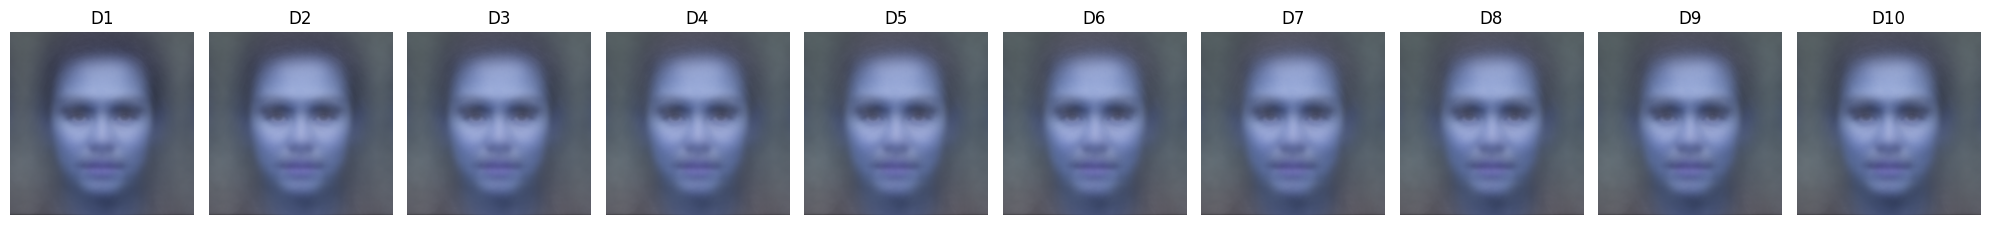

In [15]:
import matplotlib.pyplot as plt
from PIL import Image

# Load the composites back from disk
comp_images = []
for d in range(1, 11):
    path = f"composites/decile_{d:02d}.png"
    img = Image.open(path)
    comp_images.append(img)

# Display in a single row
plt.figure(figsize=(20, 4))

for i, img in enumerate(comp_images, 1):
    plt.subplot(1, 10, i)
    plt.imshow(img)
    plt.title(f"D{ i }")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Step 10 — Composite Grid (2 rows × 5 columns)

Sometimes a 10-wide row is hard to view on smaller screens.  
This alternative layout uses a 2×5 comparison grid.

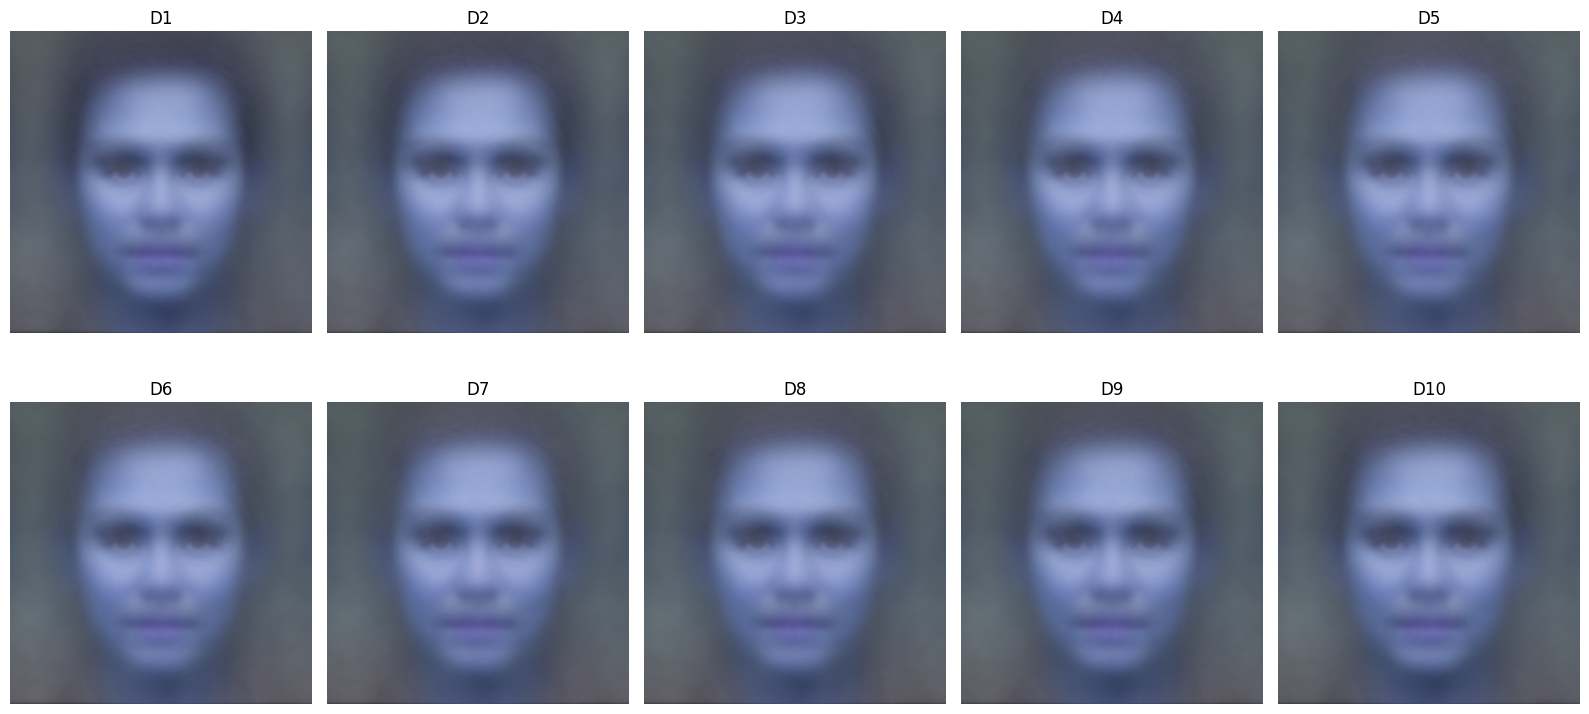

In [16]:
plt.figure(figsize=(16, 8))

for i, img in enumerate(comp_images):
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"D{ i+1 }")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Step 11 — Export Decile Group Summary

We save the following metadata into `composites/summary.json`:

- number of images per decile  
- min/max score inside each decile  
- decile index boundaries  
- the filenames used for composites  

This provides a reproducible record of how the composites were built.

In [18]:
import json
import numpy as np
import os

summary = {}

for d in range(1, 11):
    idxs = decile_groups[d]
    decile_scores = scores[idxs]

    summary[d] = {
        "count": len(idxs),
        "min_score": float(decile_scores.min()),
        "max_score": float(decile_scores.max()),
        "composite_file": f"composites/decile_{d:02d}.png"
    }

# Write summary file
os.makedirs("composites", exist_ok=True)
with open("composites/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved decile summary to composites/summary.json")


Saved decile summary to composites/summary.json


## Step 12 — Notebook Complete 🎉

You have now:

- Loaded 125k embeddings  
- Predicted attractiveness scores  
- Split portraits into deciles  
- Generated all 10 averaged composites  
- Displayed them visually  
- Exported metadata  

You may now proceed to:
- build composite sliders  
- generate side-by-side comparisons  
- integrate into the Face Stats app  
- run PCA on decile embeddings  

This completes the FaceStats composite pipeline.  